In [1]:

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from scipy.special import kn, kve
import re
import BOLEH as bl

In [7]:




gtu=3
Zetatu=2

#CKM parameters
#theta12=0.227
#theta23=4.65e-2
#theta13=4.11e-3
#delta=1.139j


#Benchmark

#yE =  np.array([[ 2.8e-6, 0, 0],
# [0, 5.9e-4, 0],
# [0, 0, 1e-2]], dtype=np.complex128)
eta  = 1e-2* np.array([[0.05*np.exp(-np.pi/2 * 1j), 0.03*np.exp(-np.pi/3 * 1j), 0.02*np.exp(-np.pi/4 * 1j) ],
 [2*4*np.exp(-np.pi/3 * 1j), 3*np.exp(-np.pi/4 * 1j), 2*np.exp(-np.pi/5 * 1j)],
                      [0,0,0]])
M   = np.array([[5e7, 0, 0],
 [0, 2* 5e7, 0],
  [0,0,0]             ])



#CKM Matrix
#V23=np.array([[ 1, 0, 0],
# [0, np.cos(theta23), np.sin(theta23)],
# [0, -np.sin(theta23), np.cos(theta23)]], dtype=np.complex128)

#V13=np.array([[np.cos(theta13) , 0, np.sin(theta13)*np.exp(-delta)],
# [0, 1, 0],
# [- np.sin(theta13)*np.exp(delta), 0, np.cos(theta13)]], dtype=np.complex128)

#V12=np.array([[np.cos(theta12) , np.sin(theta12), 0],
# [- np.sin(theta12), np.cos(theta12), 0],
# [0, 0, 1]], dtype=np.complex128)

#VCKM= V23@V13@V12

#Quark's Yukawa Couplings

#yU =  np.array([[ 4.39e-6, 0, 0],
# [0, 1.98e-3, 0],
# [0, 0, 0.4454]], dtype=np.complex128)
#yDdiag= np.array([[ 0.97e-5, 0, 0],
# [0, 1.72e-4, 0],
# [0, 0, 0.719e-2]], dtype=np.complex128)
#yD =yDdiag @ np.conj(VCKM.T) 

#parameters= {"yE": yE,
            #"yU": yU,
            #"yD":yD
 #           }

bl.config["Mref"] = M[0,0]
Mref=bl.config["Mref"]



In [8]:
M_DIAG = np.diag(M)
YNEQ_PRE = 45 / (2 * np.pi**4 * bl.geff)
Y1_DIAG = np.diag(eta @ eta.conj().T)
GAMMAN_VEC = 3*np.array([Y1_DIAG[0], Y1_DIAG[1], Y1_DIAG[2]], dtype=complex) * M_DIAG / (16 * np.pi)

def YNeq(z):
    
    x = M_DIAG * z / Mref
    res = np.zeros_like(x, dtype=float)
    
    
    mask_valid = (x > 0) & (~np.isnan(x)) & (~np.isinf(x))
    
    if np.any(mask_valid):
        xv = x[mask_valid]
        res[mask_valid] = YNEQ_PRE * xv**2 * kn(2, xv)
        
    return res 

def gammaNY(z):
    T = Mref / z
    x = M_DIAG / T 
    
    ratio = np.zeros_like(x, dtype=float)
    
    
    mask_valid = (x > 0) & (~np.isnan(x)) & (~np.isinf(x))
    
    if np.any(mask_valid):
        xv = x[mask_valid]
        
        
        mask_small = mask_valid & (x < 50)
        mask_large = mask_valid & (x >= 50)
        
        if np.any(mask_small):
            ratio[mask_small] = (
                kve(1,x[mask_small])/kve(2,x[mask_small])
            )
        
        if np.any(mask_large):
            ratio[mask_large] = (
                kve(1,x[mask_large])/kve(2,x[mask_large])
            )
        
    
    gN = GAMMAN_VEC * ratio  / (z * bl.Hubble(z))

   
    return gN

def gfunc(x):

    is_scalar = np.isscalar(x)
    x = np.atleast_1d(np.asarray(x, dtype=float))

    res = np.zeros_like(x)

    valid_mask = (x > 0) & np.isfinite(x)

    with np.errstate(divide='ignore', invalid='ignore'):

        mask_small = valid_mask & (x < 1e12)
        if np.any(mask_small):
            xs = x[mask_small]
            sqrt_xs = np.sqrt(xs)
            inv_1mxs = 1.5/(1.0-xs)

            res[mask_small] = (
                sqrt_xs
                * (
                    inv_1mxs
                    + 1.0
                    - (1.0+xs)*np.log((1.0+xs)/xs)
                )
            )

        mask_large = valid_mask & (x >= 1e12)
        if np.any(mask_large):
            xl = x[mask_large]
            sqrt_xl = np.sqrt(xl)
            inv_1mxl = 1.5/(1.0-xl)

            res[mask_large] = (
                sqrt_xl
                * (
                    inv_1mxl
                    - 0.5/xl
                )
            )

    return res[0] if is_scalar else res

In [9]:
EPS_MATS = []
P_MATS = []

for i in range(3):
    y = eta 
    y_dag = y.conj().T
    y_y_dag = y @ y_dag
    y_con = y.conj()
    
    
    num1 = np.zeros((3, 3), dtype=complex)
    num2 = np.zeros((3, 3), dtype=complex)
    Pi = np.zeros((3, 3), dtype=complex)
    eps_i = np.zeros((3, 3), dtype=complex)
    
   
    den = 32 * np.pi * y_y_dag[i, i]
    
    
    if den > 0 and M[i,i] > 0:
        
        for j in range(3):
           
            if j != i and M[j,j] > 0 and y_y_dag[j,j] > 0:
                
                
                f_vertex = gfunc(M[j,j]**2 / M[i,i]**2)
                f_self   = M[i,i]**2 / (M[i,i]**2 - M[j,j]**2)
                
                
                term_v = y_y_dag[j,i] * np.outer(y[j],y_con[i]) - y_y_dag[i,j] * np.outer( y[i], y_con[j])
                term_s = y_y_dag[i,j] * np.outer(y[j],y_con[i]) - y_y_dag[j,i] * np.outer( y[i], y_con[j])
                
                num1 += 2 * term_v * f_vertex
                num2 += 3 * term_s * f_self
                
        
        eps_i = (1j * num1 + 1j * num2) / den
        
       
        Pi = np.outer(y_con[i], y[i]) / y_y_dag[i,i]

   
    EPS_MATS.append(eps_i)
    P_MATS.append(Pi)

EPS_MATS = np.array(EPS_MATS)
P_MATS = np.array(P_MATS)

def W(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    
    YDTU = y_newphys[3]
    
    # Términos comunes
    term_u = YDU * 1/(bl.gU*bl.ZetaU)  
    term_tu = YDTU * 1/(gtu*Zetatu) 
    
    WI = sp.zeros(3, 3) if hasattr(z, 'free_symbols') else np.zeros((3, 3), dtype=complex)
    for i in range(3):
        
        Pi = P_MATS[i].T
        
        gNY_val = gammaNY(z, i) if callable(gammaNY) else gammaNY(z)[i]
        YNeq_val = YNeq(z, i) if callable(YNeq) else YNeq(z)[i]
        
        Wi = gNY_val * YNeq_val/bl.Ynor * (0.5 * (Pi @ term_u + term_u @ Pi) - (Pi * term_tu))
        WI += Wi
        
    return -0.5 * WI

def SI(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    
    if hasattr(z, 'free_symbols'): 
        Si = sp.zeros(3, 3)
    else:
        Si = np.zeros((3, 3), dtype=complex)
        
    for i in range(3):
        YN = y_newphys[i]
        gNY_val = gammaNY(z, i) if callable(gammaNY) else gammaNY(z)[i]
        YNeq_val = YNeq(z, i) if callable(YNeq) else YNeq(z)[i]
        
        Sis = EPS_MATS[i].T * gNY_val * (YN - YNeq_val)

        Si += Sis

    return -Si

def dYN(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    dYN_list = []
    
    for i in range(3):
        gNY_val = gammaNY(z, i) if callable(gammaNY) else gammaNY(z)[i]
        
        
        YNeq_val = YNeq(z, i) if callable(YNeq) else YNeq(z)[i]
        
        
        rhs_i = -gNY_val * (y_newphys[i] - YNeq_val)
        
        dYN_list.append(rhs_i)
        
    return dYN_list
    


def dYDTU(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    dYTU1 = -(SI(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD) + W(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD)).trace()
    return dYTU1


In [10]:
zspan=[1e-4,1e4]
ynew0=np.zeros(4)
Cloistered = { 
    "NEW_DEGREES_OF_FREEDOM": [dYN, dYDTU],
    "HYPERCHARGES": {3: 2/3}, #{y_newphys component, hypercharge value}
    "YDU": [W, SI]
}
funcions_to_protect = ['gammaNY', 'YNeq']

In [11]:


results =bl.SolveBE(zspan, ynew0,
    contributions=Cloistered,
    background_funcs=funcions_to_protect,
    filename='Clositered'
)


--- Jacobian Analitic Matrix---
---Lambyfy ---
Time of Jacobian calcultaion = 4.4747 seconds.
End of Jacobian and Ode
Time of numerical integration = 0.5463 seconds.
✅ Data saved successfully to HDF5: Clositered.h5
Final $B-L$ asymmetry (Full covariant formalism): 1.5653e-10


# Quark Effective

In [12]:

resultsquark =bl.SolveBEQuark(zspan,ynew0,
    contributions=Cloistered, 
    #params_sm=parameters,
    background_funcs=funcions_to_protect,
    filename='Clositered'
)


--- Analytical Jacobian Matrix ---
--- Lambdify ---
Time of Jacobian Calculation 7.2695 seconds.
End of Jacobian and Ode
Time of numerical integration = 0.4244 seconds.
✅ Data saved successfully to HDF5: ClositeredQuark.h5
Final $B-L$ asymmetry (Effective Quark-flavor covariant formalism): 1.5053e-10


Final Baryon Asymmetry Full
$Y_B=$ 1.0722172902697865e-10
Final Baryon Asymmetry Quark Eff
$Y_B^{\rm eff}=$ 1.034861453152813e-10


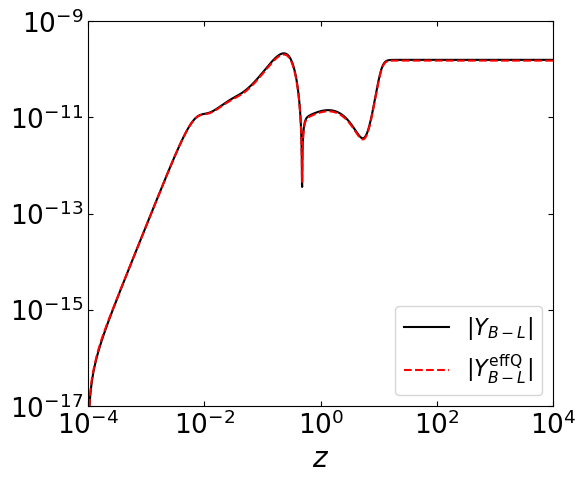

In [13]:
zQ = resultsquark["z"]
YBL_Q = resultsquark["YBL"]
y_npQ = np.array(resultsquark["y_newphys"])

z = results["z"]
YBL= results["YBL"]
y_np = np.array(results["y_newphys"])

YN = y_np[:, :3]      
YDTU = y_np[:, 3]
YN_Q = y_npQ[:, :3]      
YDTU_Q = y_npQ[:, 3]

YBSM = np.abs( 0.315*YBL[-1] +  1/3*YDTU)
YBSM_Q = np.abs( 0.315*YBL_Q[-1] +  1/3*YDTU_Q)


print("Final Baryon Asymmetry Full")
print(r'$Y_B=$',YBSM[-1])
print("Final Baryon Asymmetry Quark Eff")
print(r'$Y_B^{\rm eff}=$',YBSM_Q[-1])
plt.figure(figsize=(6, 5))

plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150


plt.rcParams['axes.labelsize'] = 20     
plt.rcParams['xtick.labelsize'] = 19    
plt.rcParams['ytick.labelsize'] = 19  
plt.rcParams['legend.fontsize'] = 16

plt.plot(
    z,
    np.abs(YBL),
    
    label=r'$|Y_{B-L}|$',
    color='black'
)
plt.plot(
    zQ,
    np.abs(YBL_Q),
    
    label=r'$|Y_{B-L}^{\rm effQ}|$',
    linestyle= '--',
    color='red'
)
title="BL Cloistered"
    
plt.xlim(1e-4,1e4)
plt.ylim(1e-17,1e-9)
plt.xlabel(r'$z$')
#plt.ylabel(r'$|Y_{B-L}|$')
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()
#plt.grid(True, which='both')

filename = re.sub(r'[^\w\s-]', '', title)
filename = filename.replace('at', '')
filename = "_".join(filename.split())
filename = filename.strip('_') + ".png"

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Sergio Cubides\AppData\Local\Temp\ipykernel_23380\1118892181.py:23: RuntimeWarning: invalid value encountered in divide
  c_H2= -(1/3)*(-tr_DQ -4*tr_DU + 2*tr_DD + 3*tr_DL


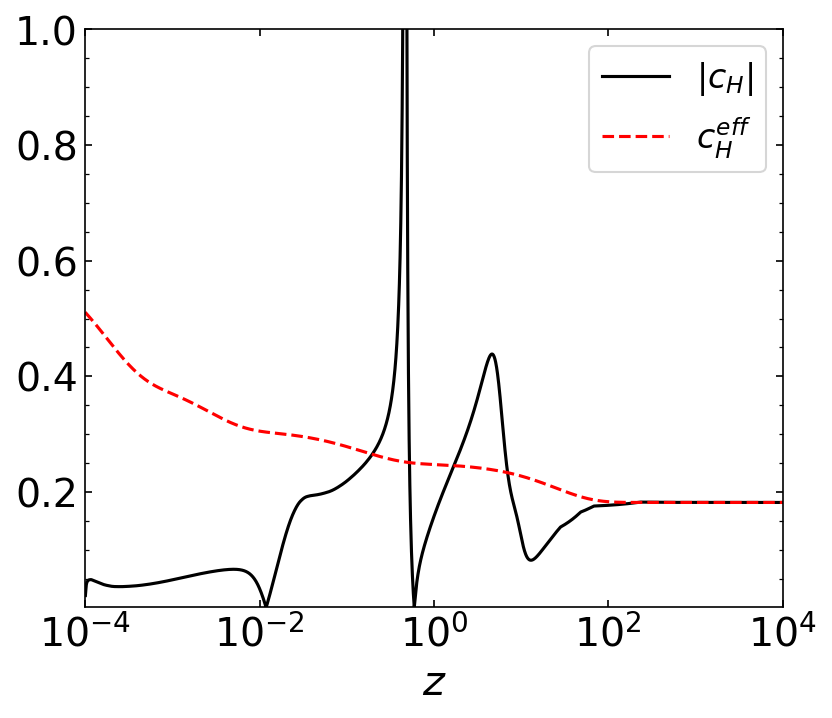

✅ Plot saved as: CH_Cloistered.png


In [9]:
#plt.figure(figsize=(8, 5))
YDL = results["YDL"]
YDE = results["YDE"]
YDQ = results["YDQ"]
YDU = results["YDU"]
YDD = results["YDD"]
tr_DL = np.array([np.trace(m) for m in YDL])
tr_DE = np.array([np.trace(m) for m in YDE])
tr_DQ = np.array([np.trace(m) for m in YDQ])
tr_DU = np.array([np.trace(m) for m in YDU])
tr_DD = np.array([np.trace(m) for m in YDD])
# 1. Set the uniform plot size
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

# 2. Set the uniform font sizes
#plt.rcParams['axes.titlesize'] = 12     # Title font size
#plt.rcParams['axes.titleweight'] = 'bold' # Bold title
plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16
c_H2= -(1/3)*(-tr_DQ -4*tr_DU + 2*tr_DD + 3*tr_DL
               +6*tr_DE-4*YDTU)/(1/3 *
    (tr_DQ + tr_DU + tr_DD)
  - tr_DL
  - 2*tr_DE+ 4/3 * YDTU)

plt.plot(
    z,
    np.abs(c_H2),
    label=r'$|c_H|$',
    color='black'
)

plt.plot(
    z,
    np.abs(bl.ch(z)),
    label=r'$c_H^{eff}$',
    color='red',
    linestyle='--'
)
title="CH Cloistered"

plt.xlim(1e-4,1e4)
plt.ylim(1e-3,1e0)
plt.xlabel(r'$z$')
#plt.ylabel(r'$c_{H}$')
plt.xscale('log')
#plt.yscale('log')
#plt.title('Normal Ordering')
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()
#plt.savefig('Trace.png', dpi=300)

filename = re.sub(r'[^\w\s-]', '', title)   
filename = filename.replace('at', '')       
filename = "_".join(filename.split())       
filename = filename.strip('_') + ".png"     


plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as: {filename}")

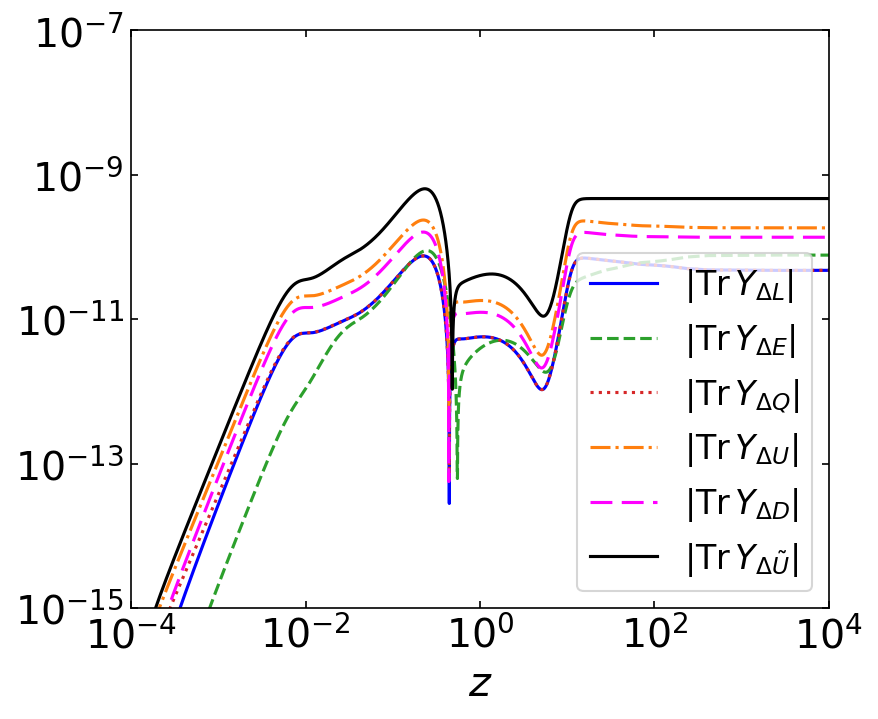

✅ Plot saved as: Ferm_Cloistered.png


In [10]:
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

# 2. Set the uniform font sizes
#plt.rcParams['axes.titlesize'] = 12     # Title font size
#plt.rcParams['axes.titleweight'] = 'bold' # Bold title
plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16
plt.plot(
    z, np.abs(tr_DL),
    lw=1.5, color='blue', ls='-',
    label=r'$|\mathrm{Tr}\,Y_{\Delta L}|$'
)

plt.plot(
    z, np.abs(tr_DE),
    lw=1.5, color='tab:green', ls='--',
    label=r'$|\mathrm{Tr}\,Y_{\Delta E}|$'
)

plt.plot(
    z, np.abs(tr_DQ),
    lw=1.5, color='tab:red', ls=':',
    label=r'$|\mathrm{Tr}\,Y_{\Delta Q}|$'
)

plt.plot(
    z, np.abs(tr_DU),
    lw=1.5, color='tab:orange', ls='-.',
    label=r'|$\mathrm{Tr}\,Y_{\Delta U}|$'
)

plt.plot(
    z, np.abs(tr_DD),
    lw=1.5, color='magenta', ls=(0, (7, 3)),
    label=r'$|\mathrm{Tr}\,Y_{\Delta D}|$'
)

plt.plot(
    z, np.abs(YDTU),
    lw=1.5, color='black', ls='-',
    label=r'$|\mathrm{Tr}\,Y_{\Delta \tilde{U}}|$'
)
title = "Ferm Cloistered"
plt.xlabel(r'$z$')
#plt.ylabel(r'$|\rm{Tr}(Y_{\Delta i})|$')
plt.xlim(1e-4,1e4)
plt.ylim(1e-15,1e-7)
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
#plt.title(title)
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()

filename = re.sub(r'[^\w\s-]', '', title)   
filename = filename.replace('at', '')       
filename = "_".join(filename.split())       
filename = filename.strip('_') + ".png"    

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as: {filename}")

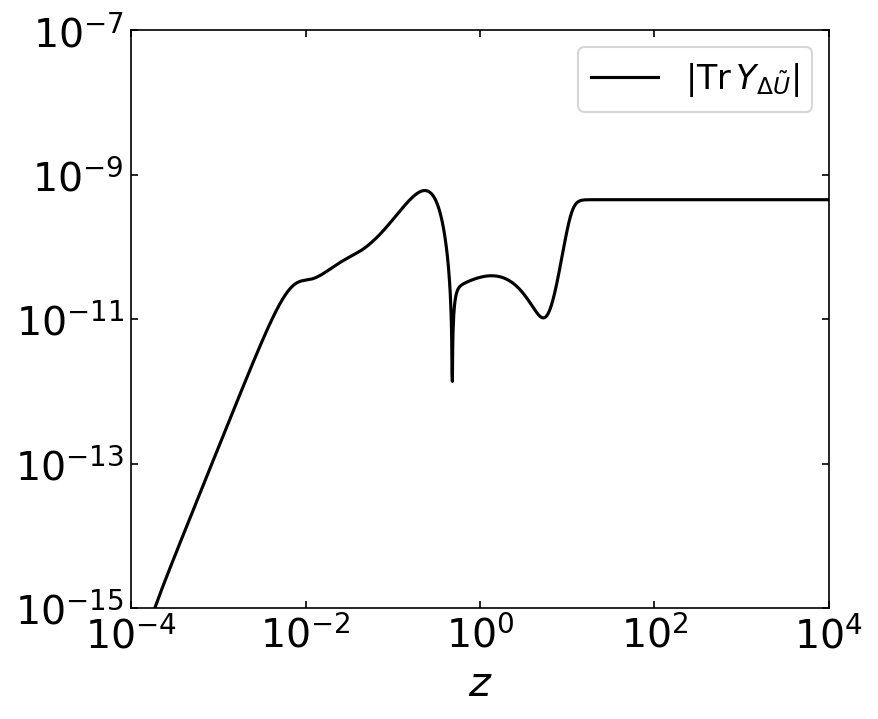

✅ Plot saved as: Ferm_Cloistered.png


In [11]:
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

# 2. Set the uniform font sizes
#plt.rcParams['axes.titlesize'] = 12     # Title font size
#plt.rcParams['axes.titleweight'] = 'bold' # Bold title
plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16

plt.plot(
    zQ, np.abs(YDTU_Q),
    lw=1.5, color='black', ls='-',
    label=r'$|\mathrm{Tr}\,Y_{\Delta \tilde{U}}|$'
)
title = "Ferm Cloistered"
plt.xlabel(r'$z$')
#plt.ylabel(r'$|\rm{Tr}(Y_{\Delta i})|$')
plt.xlim(1e-4,1e4)
plt.ylim(1e-15,1e-7)
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
#plt.title(title)
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()

filename = re.sub(r'[^\w\s-]', '', title)   
filename = filename.replace('at', '')       
filename = "_".join(filename.split())       
filename = filename.strip('_') + ".png"    

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as: {filename}")